Title

In [47]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import umap 

In [ ]:
# If necessary, navigate to the directory by entering path to directory below
os.chdir(YOUR PATH HERE)

In [49]:
df = pd.read_csv('01_data_preparation/incident_data/output_data/incidents_clustered.csv')

# Narrow down date, text fields and cliuster assignments
df = df[['start_date','name', 'description','embedding_reference', 'cluster_0_score', 'cluster_1_score', 'cluster_2_score', 'cluster_3_score', 'cluster_4_score', 'cluster_5_score', 'cluster_6_score', 'cluster_7_score', 'cluster_8_score', 'cluster_9_score', 'cluster_10_score', 'cluster_11_score', 'cluster_12_score', 'cluster_13_score', 'cluster_14_score']]
df['time-key'] = (
    pd.to_datetime(df['start_date'], format='%d.%m.%Y', errors='coerce')
    .dt.strftime('%Y-%m')
)

# Combine name and descpription into a single column
df['name_description'] = df['name'].astype(str) + ' ' + df['description'].astype(str)   

In [50]:
# Get all cluster score columns 
score_cols = [c for c in df.columns if c.startswith('cluster_') and c.endswith('_score')]

# Sort them in numerical order 
score_cols = sorted(score_cols, key=lambda x: int(x.split('_')[1]))

# Extract top keywords for each cluster
results = []

for col in score_cols:
    cluster_num = int(col.split('_')[1])
    
    # Get all name_description texts where score >= 0 for this cluster
    cluster_texts = df[df[col] > 0]['name_description'].dropna()
    
    if len(cluster_texts) == 0:
        results.append({'Cluster': f"Cluster {cluster_num}", 'Top Keywords': "No items in cluster"})
        continue

    # Combine text for TF-IDF
    combined_text = ' '.join(cluster_texts)
    
    # Run TF-IDF across all clusters
    results.append({'cluster_num': int(cluster_num), 'text': combined_text})

# Compute TF-IDF matrix
grouped_df = pd.DataFrame(results)
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), min_df=2, max_df=0.8)
tfidf_matrix = vectorizer.fit_transform(grouped_df['text'])
words = vectorizer.get_feature_names_out()

# Format final output in ascending
output = []
for idx, row in grouped_df.iterrows():
    cluster_id = f"Cluster {row['cluster_num']}"
    scores = tfidf_matrix.getrow(idx).toarray()[0]
    top_indices = scores.argsort()[-10:][::-1]
    top_keywords = ", ".join([words[i] for i in top_indices if scores[i] > 0])
    
    output.append({'Cluster': cluster_id, 'Top Keywords': top_keywords})

# Display ordered table
keywords_table = pd.DataFrame(output)
keywords_table


,Cluster,Top Keywords
0,Cluster 0,"carr, main intelligence, intelligence director..."
1,Cluster 1,"ransomware attack, ransomware group, county, l..."
2,Cluster 2,"cve, backdoor, sponsored hacking, lazarus, typ..."
3,Cluster 3,"ddos, ddos attack, ddos attacks, launched ddos..."
4,Cluster 4,"county, municipality, water, actors breached, ..."
5,Cluster 5,"anonymous vs, defaced, army, government websit..."
6,Cluster 6,"cryptocurrency, crypto, funds, lazarus, blockc..."
7,Cluster 7,"apt, backdoor, panda, espionage, aka, sponsore..."
8,Cluster 8,"university, school district, students, ransomw..."
9,Cluster 9,"espionage, spyware, pegasus, kimsuky, espionag..."


In [37]:
#save to txt file
keywords_table.to_csv('01_data_preparation/incident_data/gaussian_clusters/cluster_keywords.txt', index=False)

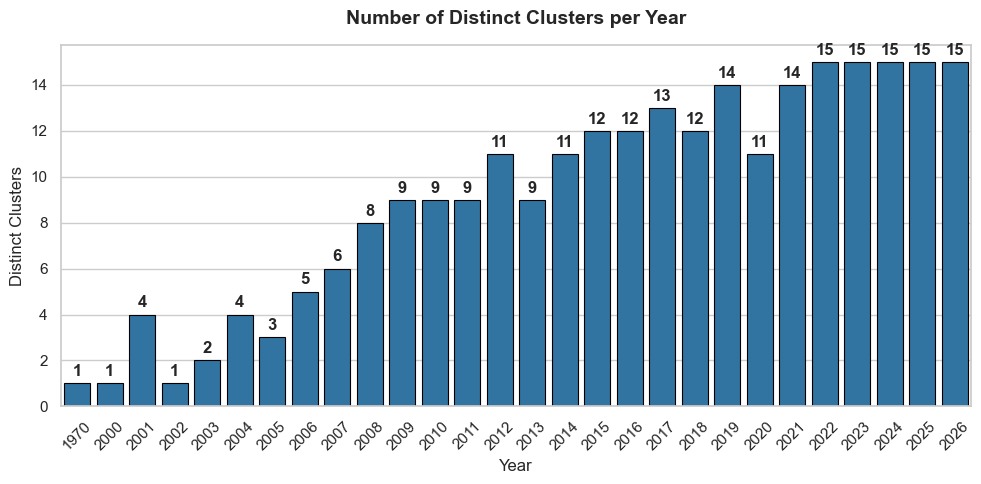

In [51]:
# Plot prevalence of distinct clusters by year
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

df['year'] = pd.to_datetime(df['start_date']).dt.year

cluster_cols = [
    c for c in df.columns if 'cluster' in c.lower() and c.endswith('_score')
]

# Calculate the number of distinct clusters (> 0) per year
yearly_clusters = (
    (df[cluster_cols] > 0)
    .groupby(df['year'])
    .any()
    .sum(axis=1)
    .rename('cluster_count')
    .reset_index()
    .astype({'year': int})
    .sort_values('year')
)

# Plot the visual
ax = sns.barplot(
    data=yearly_clusters,
    x='year',
    y='cluster_count',
    color='#1f77b4',
    edgecolor='black',
    linewidth=0.8,
)

# Add data value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontweight='bold')

plt.title(
    'Number of Distinct Clusters per Year',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Distinct Clusters', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [52]:
# Order cluster by absolute scores across all years
cluster_prevalence = df[score_cols].abs().sum().sort_values(ascending=False)
cluster_prevalence_df = cluster_prevalence.reset_index()
cluster_prevalence_df.columns = ['Cluster', 'Prevalence']
print(cluster_prevalence_df)
cluster_prevalence_df.to_csv('01_data_preparation/incident_data/gaussian_clusters/cluster_prevalence.txt', index=False)

             Cluster  Prevalence
0    cluster_5_score        5974
1    cluster_2_score        3977
2   cluster_12_score        3870
3    cluster_7_score        3584
4   cluster_10_score        3275
5    cluster_9_score        3137
6    cluster_1_score        2950
7   cluster_14_score        2851
8    cluster_0_score        2692
9    cluster_4_score        2614
10  cluster_13_score        2357
11  cluster_11_score        2264
12   cluster_8_score        2179
13   cluster_3_score        1984
14   cluster_6_score        1339


In [48]:
!pip install umap-learn


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


/var/folders/ph/qt16mchj0gn69_ry7t59zdf40000gn/T/ipykernel_72395/2783341580.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=5, alpha=0.6, cmap='Spectral')


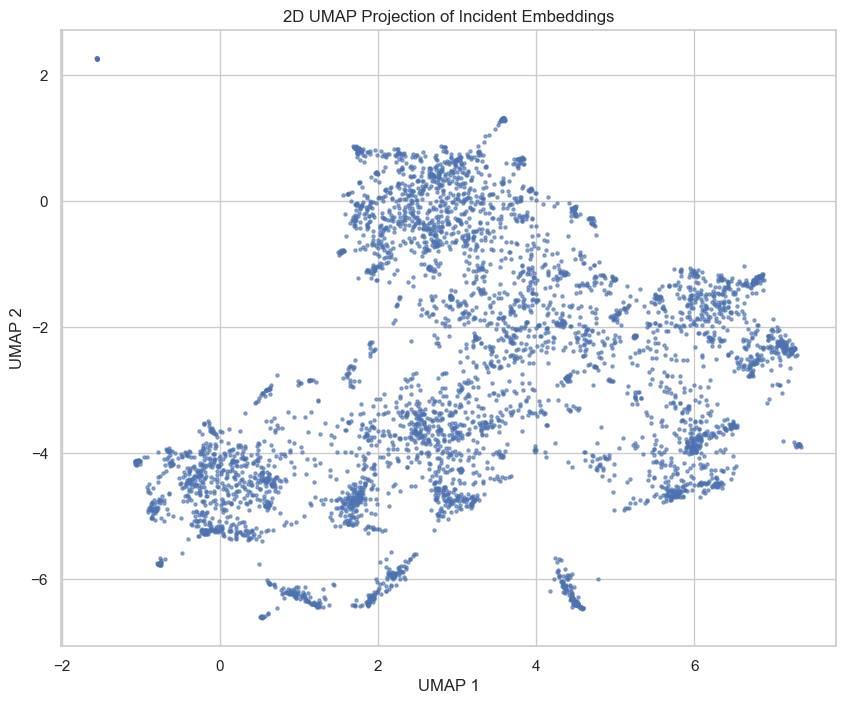

In [54]:
embeddings_2d = np.load('01_data_preparation/incident_data/gaussian_clusters/embeddings_2d.npy')

plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=5, alpha=0.6, cmap='Spectral')
plt.title('2D UMAP Projection of Incident Embeddings')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

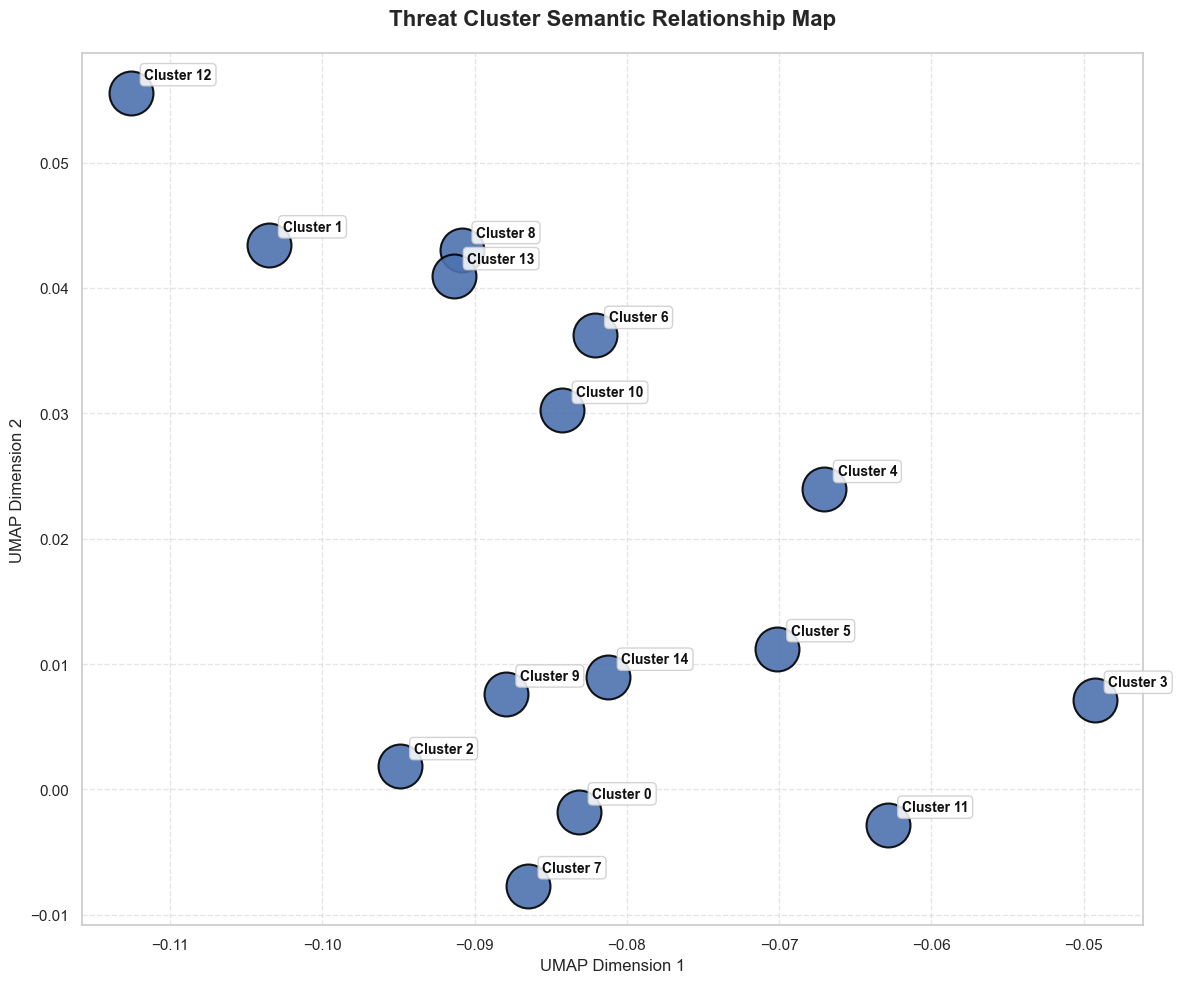

In [55]:
centroids = np.load('01_data_preparation/incident_data/gaussian_clusters/cluster_centroids.npy')

plt.figure(figsize=(12, 10))

plt.scatter(
    centroids[:, 0], 
    centroids[:, 1], 
    s=1000,                    
    edgecolor='black', 
    linewidth=1.5,
    alpha=0.9
)

for i in range(len(centroids)):
    x, y = centroids[i, 0], centroids[i, 1]
    label_text = f"Cluster {i}"
    
    plt.annotate(
        label_text,
        (x, y),
        xytext=(10, 10),                     
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
        color='#111111',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#cccccc", alpha=0.85) 
    )

plt.title('Threat Cluster Semantic Relationship Map', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [56]:
# Get Cluster Emergence Year
df['year'] = pd.to_datetime(df['start_date'], errors='coerce').dt.year
cluster_cols = [
    c for c in df.columns if 'cluster' in c.lower() and c.endswith('_score')
]
first_years = pd.Series({
    col: df.loc[df[col].notna() & (df[col] != 0), 'year'].min() for col in cluster_cols
})
print(first_years)

cluster_0_score     1970.0
cluster_1_score     2015.0
cluster_2_score     2003.0
cluster_3_score     2001.0
cluster_4_score     2016.0
cluster_5_score     2000.0
cluster_6_score     2014.0
cluster_7_score     2005.0
cluster_8_score     2009.0
cluster_9_score     2003.0
cluster_10_score    2001.0
cluster_11_score    2008.0
cluster_12_score    2017.0
cluster_13_score    2012.0
cluster_14_score    2004.0
dtype: float64


In [75]:
# Order by average score by column above 0
avg_score = df[df[score_cols] > 0]
avg_score = avg_score[score_cols].mean().sort_values(ascending=False)
print(avg_score)


cluster_6_score     9.992537
cluster_8_score     9.949772
cluster_5_score     9.745514
cluster_13_score    9.739669
cluster_3_score     9.631068
cluster_11_score    9.512605
cluster_4_score     9.302491
cluster_10_score    9.122563
cluster_12_score    9.000000
cluster_1_score     8.858859
cluster_0_score     8.132931
cluster_14_score    8.053672
cluster_7_score     8.035874
cluster_9_score     8.023018
cluster_2_score     7.767578
dtype: float64
